# Create Clean Data Structures

In [114]:
# 🌴 Palm Oil Yield Prediction 
# This notebook performs analysis and prediction of palm oil yield using random forest.

## Objectives:
#- Analyze relationship between variables
#- Build prediction model
#- Evaluate model performance

# Library
import pandas as pd

# Load Data
df = pd.read_csv("datasetKS2.csv")
df["tanggal_panen"] = pd.to_datetime(
    df["tanggal_panen"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df['yield_kg_ha'] = df['produksi'] / df['luas_ha']

df = df.sort_values(by='tanggal_panen')

subset = df[[
    'tanggal_panen',
    'luas_ha',
    'umur_tanaman',
    'populasi_ha',
    'produksi',
    'pupuk_npk',
    'curah_hujan',
    'sex_ratio',
    'yield_kg_ha'
]]
print(subset.head(10))

   tanggal_panen  luas_ha  umur_tanaman  populasi_ha  produksi  pupuk_npk  \
0     2025-01-01       25            57          124   1593.35        250   
36    2025-01-01       28            86          145   2071.56        250   
12    2025-01-01       30            99          135   1903.34          0   
24    2025-01-01       22            63          143   1673.00          0   
60    2025-01-01       26           139          142   1688.58          0   
48    2025-01-01       24            59          134   1700.33          0   
61    2025-02-01       26           139          142   2080.91        250   
49    2025-02-01       24            59          134   1862.92        250   
37    2025-02-01       28            86          145   2253.33        150   
13    2025-02-01       30            99          135   1867.48        150   

    curah_hujan  sex_ratio  yield_kg_ha  
0         151.4       0.64    63.734000  
36        197.8       0.64    73.984286  
12        200.2       0.59

# Correlation Analysis

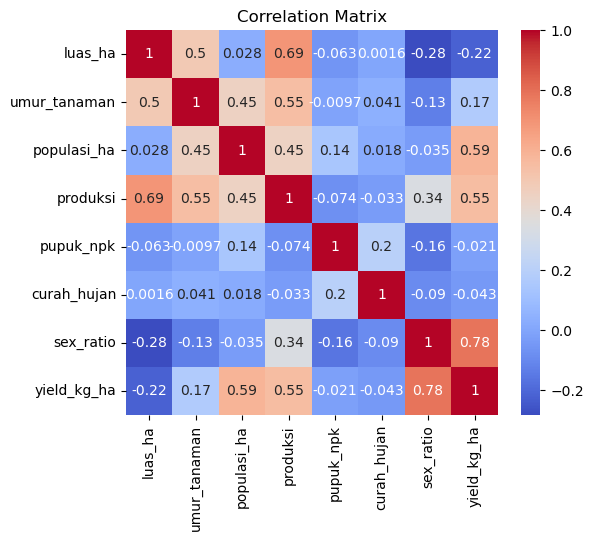

--- Sex Ratio vs Yield Correlation ---
Correlation_Sr: 0.784381609132884
P-value_Sr: 3.636559835138902e-16


In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Correlation
corr_matrix = df[[
    'luas_ha',
    'umur_tanaman',
    'populasi_ha',
    'produksi',
    'pupuk_npk',
    'curah_hujan',
    'sex_ratio',
    'yield_kg_ha'
]].corr()

# Visualitation
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

print("--- Sex Ratio vs Yield Correlation ---")
corr, p_value = pearsonr(df['sex_ratio'], df['yield_kg_ha'])
print("Correlation_Sr:", corr)
print("P-value_Sr:", p_value)

# Training Machine Learing (Random Forest)

In [116]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Modeling
X = df[[
    'luas_ha',
    'umur_tanaman',
    'populasi_ha',
    'produksi',
    'pupuk_npk',
    'curah_hujan',
    'sex_ratio',
]]
y = df['yield_kg_ha']

# Split Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Evaluation


--- Model Evaluation ---
Akurasi (R2 Score): 0.96
Kesalahan (MSE): 1.27


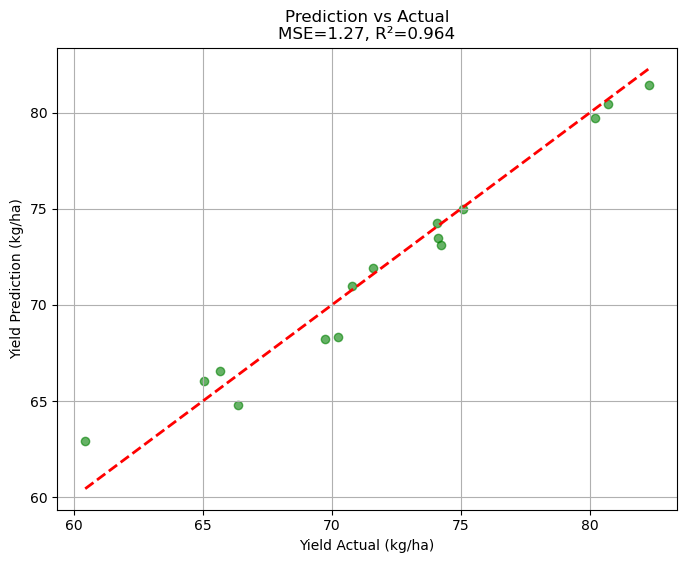

In [117]:
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Akurasi (R2 Score): {r2:.2f}")
print(f"Kesalahan (MSE): {mse:.2f}")

# Visualitation MSE & R²
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', lw=2)  # garis ideal
plt.xlabel('Yield Actual (kg/ha)')
plt.ylabel('Yield Prediction (kg/ha)')
plt.title(f'Prediction vs Actual\nMSE={mse:.2f}, R²={r2:.3f}')
plt.grid(True)
plt.show()

# SHAP Summary Plot

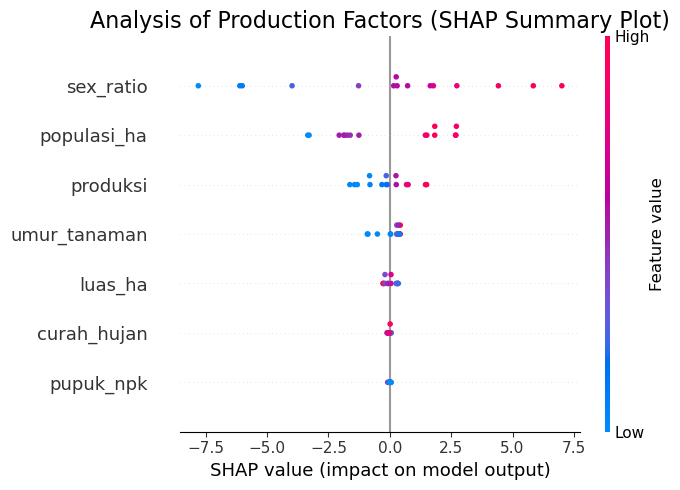

In [118]:
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 3. MEMBUAT SHAP SUMMARY PLOT
# a. Buat Explainer khusus untuk model berbasis pohon (TreeExplainer)
explainer = shap.TreeExplainer(rf_model)

# b. Hitung SHAP values untuk data uji (X_test)
shap_values = explainer.shap_values(X_test)

# c. Visualisasikan SHAP Summary Plot
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False, plot_size=(7, 5))

# Tambahkan Judul dan Tampilkan
plt.title("Analysis of Production Factors (SHAP Summary Plot)", fontsize=16)
plt.tight_layout()
plt.show()

# Prediction Analysis

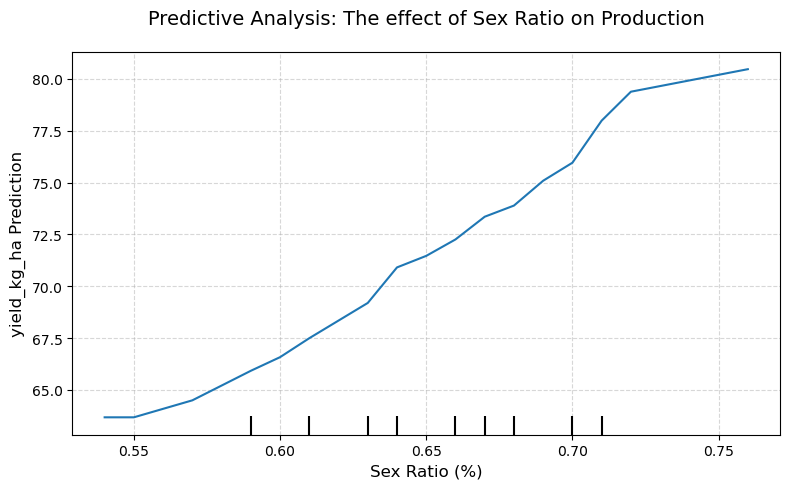

In [119]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Membuat area gambar
fig, ax = plt.subplots(figsize=(8, 5))

# Menggunakan Partial Dependence (Murni pendapat model Random Forest)
PartialDependenceDisplay.from_estimator(rf_model, X_train, features=['sex_ratio'], ax=ax)

# Grafik Prediksi
plt.title("Predictive Analysis: The effect of Sex Ratio on Production", fontsize=14, pad=20)
plt.xlabel("Sex Ratio (%)", fontsize=12)
plt.ylabel("yield_kg_ha Prediction", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Key Insights
#- Model shows very high accuracy (R² close to 1)
#- Strong relationship between independent variables and yield
#- Model can be used as baseline prediction tool

# Land Cluster Distribution (K-Means)

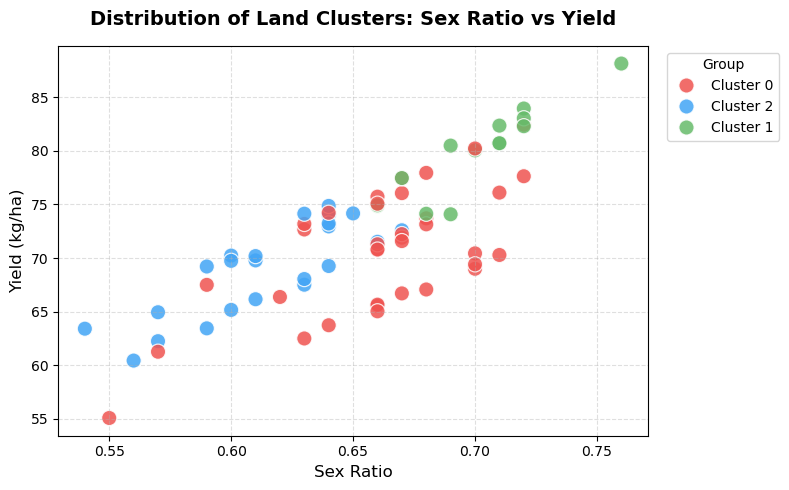

In [120]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# FULL CLUSTERING & VISUALIZATION SCRIPT FOR JUPYTER (SEABORN VERSION)
# --- PART 1: DATA PREPARATION, SCALING, & CLUSTERING ---
# 1. Fitur
features = df[[
    'luas_ha',
    'umur_tanaman',
    'populasi_ha',
    'produksi',
    'pupuk_npk',
    'curah_hujan',
    'sex_ratio',
    'yield_kg_ha'
]]

# 2. Aktifkan StandardScaler (Membuat data seragam untuk AI)
scaler = StandardScaler()
# scaled_data berisi angka desimal kecil agar K-Means adil
scaled_data = scaler.fit_transform(features) 

# 3. K-Means Clustering (Menggunakan data yang sudah di-scale)
kmeans = KMeans(
    n_clusters=3, 
    random_state=42
)
df['cluster'] = kmeans.fit_predict(scaled_data) 

# --- PART 2: LABELING & COLOR SETUP ---
# Menggunakan List Comprehension (Cara paling aman)
df['cluster_label'] = ['Cluster ' + str(c) for c in df['cluster']]

# Setup warna premium untuk Seaborn
premium_colors = {
    'Cluster 0': '#EF5350', # Merah Coral
    'Cluster 1': '#66BB6A', # Hijau Zamrud
    'Cluster 2': '#42A5F5'  # Biru Langit
}

# --- PART 3: VISUALIZATION 1 (SEX RATIO VS YIELD) ---
# Menggunakan Matplotlib dan Seaborn agar dijamin muncul di Jupyter
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='sex_ratio',
    y='yield_kg_ha',
    hue='cluster_label',
    palette=premium_colors,
    s=120,       # Ukuran titik
    alpha=0.85,  # Sedikit transparan agar titik yang menumpuk tetap terlihat
    edgecolor='white' # Garis putih halus di sekitar titik agar elegan
)

# Kustomisasi tampilan grafik
plt.title('Distribution of Land Clusters: Sex Ratio vs Yield', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sex Ratio', fontsize=12)
plt.ylabel('Yield (kg/ha)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Pindahkan legenda ke luar grafik
plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout() # Mencegah teks terpotong

# Tampilkan grafik pertama
plt.show()

# PCA Visualization

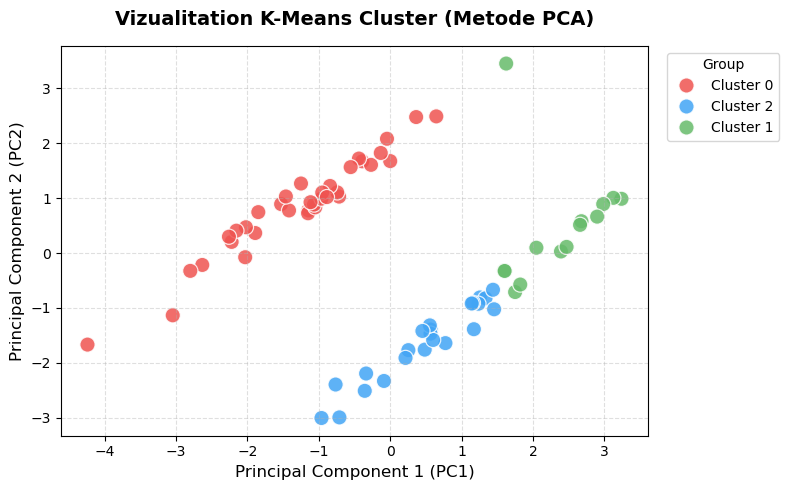

In [121]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- PART 4: VISUALIZATION 2 (PCA - PRINCIPAL COMPONENT ANALYSIS) ---
# Memeras dimensi menjadi 2D menggunakan PCA pada 'scaled_data'
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

# Masukkan hasil PCA ke dataframe
df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

# Buat kanvas grafik kedua
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='cluster_label',
    palette=premium_colors,
    s=120,
    alpha=0.85,
    edgecolor='white'
)

# Kustomisasi tampilan grafik PCA
plt.title('Vizualitation K-Means Cluster (Metode PCA)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Pindahkan legenda ke luar grafik
plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Tampilkan grafik kedua
plt.show()

# Outlier Check (PCA Analysis)

In [122]:
from IPython.display import display

# Mencari blok dengan nilai PC2 tertinggi (karena titik itu paling tinggi di sumbu Y)
outlier = df.sort_values('PC2', ascending=False).head(1)

# Membandingkan Outlier dengan Rata-rata Cluster
# Blok asing (Outlier)
print("\n--- Strange Block Data (OUTLIER) ---")
print(outlier[['kode_blok', 'yield_kg_ha', 'sex_ratio', 'pupuk_npk', 'umur_tanaman', 'curah_hujan']])

# 1. Menghitung rata-rata fitur penting untuk setiap cluster
cluster_summary = df.groupby('cluster_label')[[
    'yield_kg_ha', 
    'sex_ratio', 
    'pupuk_npk', 
    'umur_tanaman',
    'curah_hujan'
]].mean()

# 2. Menambahkan kolom jumlah blok agar tahu seberapa besar anggota tiap kelompok
cluster_summary['jumlah_blok'] = df['cluster_label'].value_counts()

# 3. Menampilkan tabel ringkasan
print("\n--- ANALISIS PROFIL TIAP CLUSTER ---")
display(cluster_summary.sort_index().style.background_gradient(cmap='YlGn'))


--- Strange Block Data (OUTLIER) ---
   kode_blok  yield_kg_ha  sex_ratio  pupuk_npk  umur_tanaman  curah_hujan
29       B01    88.123636       0.76        250            63         94.8

--- ANALISIS PROFIL TIAP CLUSTER ---


,yield_kg_ha,sex_ratio,pupuk_npk,umur_tanaman,curah_hujan,jumlah_blok
cluster_label,,,,,,
Cluster 0,70.846805,0.662286,88.571429,59.571429,146.628571,35
Cluster 1,79.790237,0.700000,67.857143,108.928571,108.671429,14
Cluster 2,69.005655,0.613913,117.391304,105.478261,170.104348,23


# Block Check (PCA Analysis)

In [123]:
# Mencari blok yang ingin dicek
cari_blok = "B01"

hasil = df[df['kode_blok'] == cari_blok][['kode_blok', 'cluster_label', 'yield_kg_ha', 'sex_ratio']]
display(hasil)

,kode_blok,cluster_label,yield_kg_ha,sex_ratio
24,B01,Cluster 0,76.045455,0.67
25,B01,Cluster 0,82.434545,0.72
26,B01,Cluster 0,72.659091,0.63
27,B01,Cluster 0,73.177273,0.63
28,B01,Cluster 0,77.445000,0.67
29,B01,Cluster 1,88.123636,0.76
30,B01,Cluster 0,67.497273,0.59
31,B01,Cluster 0,75.716364,0.66
32,B01,Cluster 0,77.935455,0.68
33,B01,Cluster 0,80.208182,0.70


# Filtering Cluster Blocks

In [124]:
from IPython.display import display

# FILTER: MENCARI DAFTAR BLOK DALAM CLUSTER TERTENTU
# Pilih cluster
target_cluster = 1 

# Melakukan filter dan mengambil kolom penting saja
blok_dalam_cluster = df[df['cluster'] == target_cluster][['kode_blok', 'yield_kg_ha', 'sex_ratio', 'umur_tanaman']]

# Mengurutkan berdasarkan yield tertinggi agar tahu siapa "juara" di cluster ini
blok_dalam_cluster = blok_dalam_cluster.sort_values(by='yield_kg_ha', ascending=False)

print(f"--- Block in a Cluster {target_cluster} ({len(blok_dalam_cluster)} Data rows) ---")
display(blok_dalam_cluster)

--- Block in a Cluster 1 (14 Data rows) ---


,kode_blok,yield_kg_ha,sex_ratio,umur_tanaman
29,B01,88.123636,0.76,63
41,B02,83.932857,0.72,86
42,B02,83.022143,0.72,86
45,B02,82.338929,0.71,86
70,C02,82.283077,0.72,139
66,C02,80.713462,0.71,139
71,C02,80.700000,0.71,139
37,B02,80.476071,0.69,86
61,C02,80.035000,0.70,139
43,B02,77.453214,0.67,86
